## Autograd
- [source code](https://github.com/karpathy/micrograd)
- [Video](https://www.youtube.com/watch?v=VMj-3S1tku0&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ)
- [Define customized autograd functions in pytorch](https://docs.pytorch.org/tutorials/beginner/examples_autograd/polynomial_custom_function.html)

- The autograd project only works on scalar-value because it is only for pedagogical purpose. In production, the code should works with tensor to utilize the parallel processing power of computer.


In [137]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from graphviz import Digraph

## Computation Graph

In [138]:
def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

## Value Node
- [multi-variable chiain rule](https://www.youtube.com/watch?v=9yCtWfI_Vjg&t=347s)

In [139]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        # Default 0.0 is for multivariable 
        self.grad = 0.0
        self._backward = lambda: None
        # for backward propagation
        self._prev = _children
        # for computation graph
        self._op = _op
        # for computation graph
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(
            self.data + other.data,
            _children = (self, other),
            _op = "+",
            label = f"{self.label}+{other.label}"
        )

        def _backward():
            # += for mutlivarable chain rule
            self.grad += out.grad
            other.grad += out.grad
        
        out._backward = _backward
        
        return out

        

    def __mul__(self, other):
        out = Value(
            self.data * other.data,
            _children = (self, other),
            _op = "*",
            label = f"{self.label}*{other.label}"
        )

        def _backward():
            # += for mutlivarable
            # * for chain rule
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        
        out._backward = _backward
        
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, _children = (self,), _op="tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward

        return out

    def backward(self):
        seen = set()
        topo_list = []
        self.grad = 1.0
        
        def build_topo(v):
            if v not in seen:
                seen.add(v)
                for child in v._prev:
                    build_topo(child)
                topo_list.append(v)
        build_topo(self)

        for node in reversed(topo_list):
            node._backward()



## Discet single Neuron of Neural Netowrk
- input: (2,)
- output: (1,)
- activation function: tanh

In [140]:
def create_demo_neuron():
    x1 = Value(2, label="x1")
    w1 = Value(-3, label="w1")
    x2 = Value(0, label="x2")
    w2 = Value(1, label="w2")
    # bias of the neuron
    # The value is just making the backward propagation value beautiful
    b = Value(6.8813735870195432, label='b')
    
    x1w1 = x1 * w1;
    x2w2 = x2 * w2
    
    x1w1x2w2 = x1w1 + x2w2;
    
    z = x1w1x2w2 + b; z.label = "z"
    
    o = z.tanh()
    o.label = "o"
    return (o, z, x1w1x2w2, x1w1, x2w2)

### Manual Backward 

In [141]:
o, z, x1w1x2w2, x1w1, x2w2 = create_demo_neuron()
o.grad = 1
o._backward()
z._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

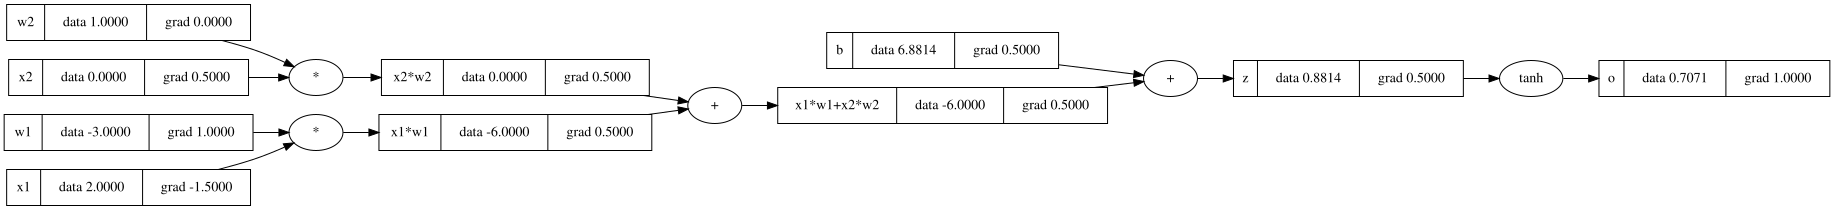

In [142]:
draw_dot(o)

### Auot Backward
- We need go thorugh all nodes in topological sorted list based on neural network neruon structure.

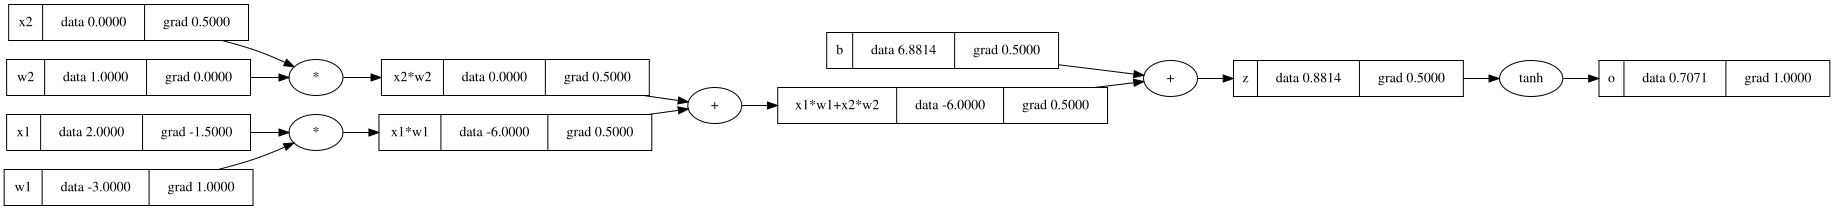

In [143]:
o, _, _, _, _ = create_demo_neuron()
o.backward()
draw_dot(o)

### Multivarible Case

In [144]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b    ; d.label = 'd'
e = a + b    ; e.label = 'e'
f = d * e    ; f.label = 'f'

f.backward()

draw_dot(f)


"""
df/db demo

case 1
df/db = dd/db * df/dd = -2 * 1 = -2
case 2
df/db = de/db * df/de = 1 * -6  = -6

Multivariable chian rule
df/db = -2 + -6 = -8
"""

'\ndf/db demo\n\ncase 1\ndf/db = dd/db * df/dd = -2 * 1 = -2\ncase 2\ndf/db = de/db * df/de = 1 * -6  = -6\n\nMultivariable chian rule\ndf/db = -2 + -6 = -8\n'

## Value Node Second Half
- Karpatyh design this part jsut to let use practice more granular operation like division, exp, etc.
- Operators to pracrtice (only handles Value + constant)
  - __truediv__
  - __neg__
  - __sub__
  - __pow__
  - etc
- Operators that handle the order of slef and other (handle cases that constant + Value)
  - __rmul__
  - __radd__
  - __rtruediv__
  - etc

I skip this part, because the concept is same as before. Just copy and paste the code from [here](https://github.com/karpathy/nn-zero-to-hero/blob/master/lectures/micrograd/micrograd_lecture_second_half_roughly.ipynb)

In [145]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward
    
    return out
  
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

<hr/>

## Neural Network Framework Implementation (Torch)
- tensor.data.item() == tensor.item()
- `.double`: get `float64` which is consistent with python. In default, Tensor type data as `float32`.

In [146]:
import torch
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
z = x1*w1 + x2*w2 + b
o = torch.tanh(z)
o.backward()

print("inference result: ", o.item())
print("x1_grad: ", x1.grad.item())
print("w1_grad: ", w1.grad.item())
print("x2_grad: ", x2.grad.item())
print("w2_grad: ", w2.grad.item())


inference result:  0.7071066904050358
x1_grad:  -1.5000003851533106
w1_grad:  1.0000002567688737
x2_grad:  0.5000001283844369
w2_grad:  0.0


## Neural Network Implemetation

### Key Entities
1. Neuron
2. Layer
3. MLP

In [207]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
  
    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
  
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [208]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])

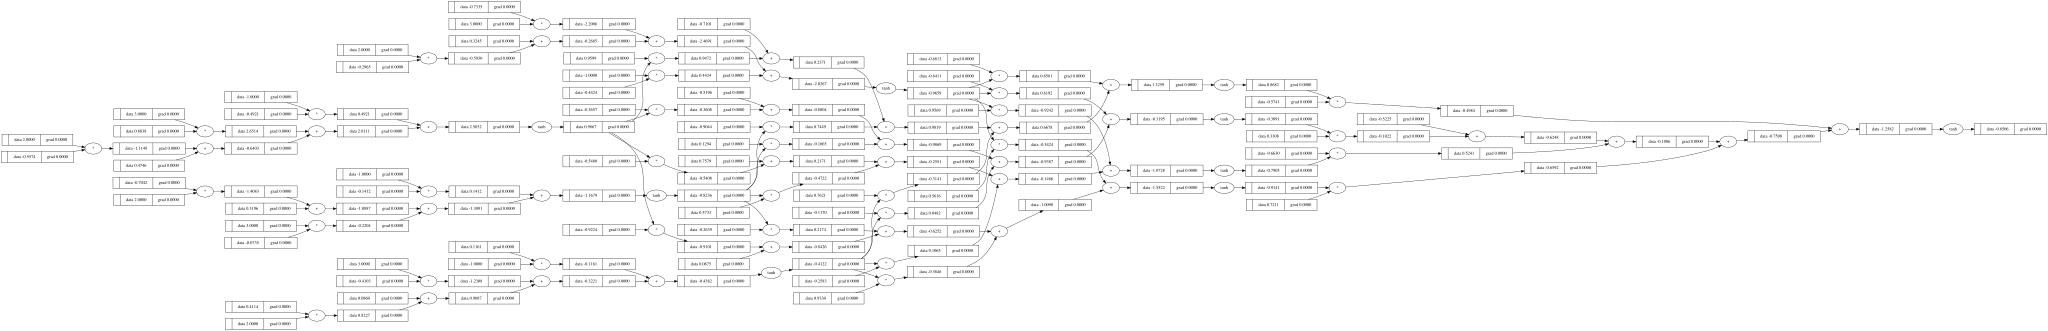

In [209]:
draw_dot(n(x))

## Train Process
### Background Knowledge
During the backward process, all computation nodes compute their gradients using the chain rule in reverse topological order. The backward pass starts from the loss node, which is the output of the computation graph.

Each gradient represents the partial derivative of the loss with respect to a parameter, indicating how a small change in that parameter affects the loss. If the gradient is positive, increasing the parameter will locally increase the loss; if it is negative, increasing the parameter will locally decrease the loss.

Because gradients accumulate across backward passes, all gradients must be reset to zero before starting each backward process. Gradients accumulate because the multivariable chain rule requires summing gradient contributions from multiple computational paths within a single backward pass. Since gradient accumulation is implemented using +=, gradients persist across backward calls unless explicitly reset, which is why all gradients must be zeroed before each training iteration.

### Key Steps
1. Forward propagation
2. Compute loss
3. backward propagation
4. Gradeint descent

### Input & Output

In [210]:
# 4 separate inputs
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets


Just to illustrate that the last node of Neural Network is the loss node

In [211]:
predictions = [n(x) for x in xs]
loss = sum((pred - ys)**2 for ys, pred in zip(ys, predictions))

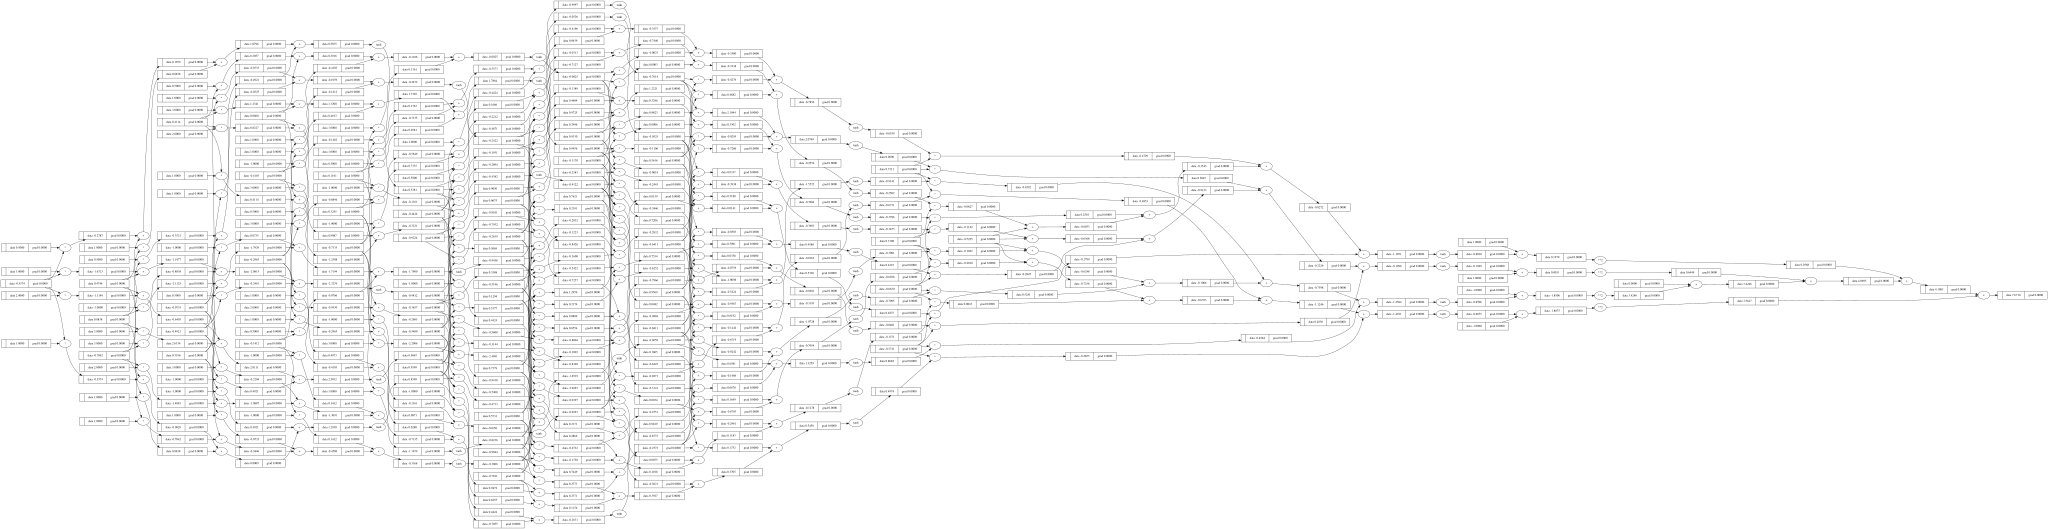

In [212]:
draw_dot(loss)

### Traing Implementation

In [218]:
for _ in range(20):
    # forward propagation
    predictions = [n(x) for x in xs]

    # loss computation
    loss = sum((pred - ys)**2 for ys, pred in zip(ys, predictions))
    
    # reset grads to 0
    for p in n.parameters():
        p.grad = 0

    # backward propagation to get gradients so that we know how to update params
    loss.backward()

    # gradient descent
    for p in n.parameters():
        p.data += -0.1 * p.grad

    print(f"Iteration: {_}, loss: {loss.data}")

Iteration: 0, loss: 0.008577942264353254
Iteration: 1, loss: 0.008337941206724122
Iteration: 2, loss: 0.008110622137717585
Iteration: 3, loss: 0.007895014413846928
Iteration: 4, loss: 0.007690243615325595
Iteration: 5, loss: 0.007495519932640025
Iteration: 6, loss: 0.007310128193769475
Iteration: 7, loss: 0.0071334192680214785
Iteration: 8, loss: 0.006964802629904829
Iteration: 9, loss: 0.006803739904533521
Iteration: 10, loss: 0.006649739246761515
Iteration: 11, loss: 0.0065023504311376
Iteration: 12, loss: 0.00636116055004322
Iteration: 13, loss: 0.006225790233963855
Iteration: 14, loss: 0.006095890321476866
Iteration: 15, loss: 0.005971138917789628
Iteration: 16, loss: 0.005851238789983507
Iteration: 17, loss: 0.005735915054874103
Iteration: 18, loss: 0.0056249131218714735
Iteration: 19, loss: 0.005517996858648049


In [219]:
print('predictions:', predictions)

predictions: [Value(data=0.9728603561636999), Value(data=-0.9703387147453981), Value(data=-0.9610209540023728), Value(data=0.951191407301103)]
